In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../Data/processed/features_final.parquet')
print(df.shape)

(307511, 183)


In [2]:
# Columnas categoricas
cat_cols = df.select_dtypes(include='str').columns.tolist()
print(f'Total de columnas categoricas: {len(cat_cols)}')
print(cat_cols)

Total de columnas categoricas: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [3]:
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} categorías')

NAME_CONTRACT_TYPE: 2 categorías
CODE_GENDER: 3 categorías
FLAG_OWN_CAR: 2 categorías
FLAG_OWN_REALTY: 2 categorías
NAME_TYPE_SUITE: 7 categorías
NAME_INCOME_TYPE: 8 categorías
NAME_EDUCATION_TYPE: 5 categorías
NAME_FAMILY_STATUS: 6 categorías
NAME_HOUSING_TYPE: 6 categorías
OCCUPATION_TYPE: 18 categorías
WEEKDAY_APPR_PROCESS_START: 7 categorías
ORGANIZATION_TYPE: 58 categorías
FONDKAPREMONT_MODE: 4 categorías
HOUSETYPE_MODE: 3 categorías
WALLSMATERIAL_MODE: 7 categorías
EMERGENCYSTATE_MODE: 2 categorías


Para las columnas con alta cardinalidad usaremos label encoding, que asigna un entero a cada categoría. Para el resto usaremos one-hot encoding que crea una columna binaria por cada categoria.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']:
    df[col] = le.fit_transform(df[col].astype('str'))

In [5]:
# Verificamos que la transformacion haya sido correcta
print(df[['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']].dtypes)

OCCUPATION_TYPE      int64
ORGANIZATION_TYPE    int64
dtype: object


In [6]:
cat_cols_ohe = [c for c in df.select_dtypes(include='str').columns]

df = pd.get_dummies(df, columns=cat_cols_ohe, drop_first=True)

df.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FONDKAPREMONT_MODE_reg oper spec account,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,False,False,False,False,False,False,False,True,False,False
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,...,False,False,False,False,False,False,True,False,False,False
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,...,False,False,False,False,False,False,True,False,False,False
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,...,False,False,False,False,False,False,True,False,False,False


In [7]:
# Separacion de datos en variables y target
X = df.copy().drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET'].copy()

print(X.shape)
print(y.shape)

(307511, 217)
(307511,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(246008, 217)
(61503, 217)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalamos los datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reemplazamos caracteres conflictivos en los nombres de las columas
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# Convertimos en DataFrame nuevamente para evitar conflictos con modelos
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:,1]

auc_dummy = roc_auc_score(y_test, y_prob_dummy)
print(f'Baseline AUC-ROC: {auc_dummy:.4f}')

Baseline AUC-ROC: 0.5000


Primer modelo real: Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(random_state=42, max_iter=1000)

scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')

print(f'AUC-ROC por fold: {scores.round(4)}')
print(f'AUC-ROC medio: {scores.mean():.4f} (+/- {scores.std():.4f})')

AUC-ROC por fold: [0.7497 0.7382 0.7488 0.7513 0.7495]
AUC-ROC medio: 0.7475 (+/- 0.0047)


Segundo modelo: Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

print(f'AUC-ROC por fold: {scores_rf.round(4)}')
print(f'AUC-ROC medio: {scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})')

AUC-ROC por fold: [0.7258 0.7147 0.724  0.7243 0.7234]
AUC-ROC medio: 0.7225 (+/- 0.0039)


Tercer modelo: LightGBM

In [29]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1
)

scores_lgb = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='roc_auc')

print(f'AUC-ROC por fold: {scores_lgb.round(4)}')
print(f'AUC-ROC medio: {scores_lgb.mean():.4f} (+/- {scores_lgb.std():.4f})')

AUC-ROC por fold: [0.7618 0.7484 0.7618 0.7635 0.7588]
AUC-ROC medio: 0.7589 (+/- 0.0055)


In [30]:
lgbm_final = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1
)

lgbm_final.fit(X_train, y_train)
y_prob = lgbm_final.predict_proba(X_test)[:, 1]

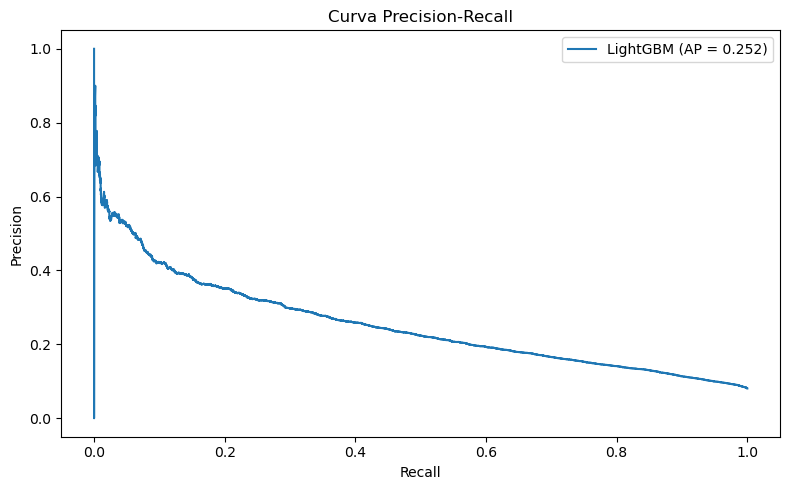

In [42]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(recall, precision, label=f'LightGBM (AP = {ap:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall')
ax.legend()
plt.tight_layout()
plt.savefig('../Reports/figures/09_precision_recall.png')
plt.show()

Mejor umbral para Precision y Recall

In [43]:
from sklearn.metrics import f1_score

'''
Para reducir el coste computacional al calcular los f1 para cada umbral, se crea un conjunto de 200 umbrales, con el que se hará la comparación convirtiendo las probabilidades y los umbrales en matrices. Luego calculamos el F1 para cada columna de esta matriz resultante.
'''

# thresholds_reducidos = np.linspace(0.01, 0.99, 200)

# predicciones = (y_prob[:, np.newaxis] >= thresholds_reducidos[np.newaxis, :]).astype(int) 

# f1_scores = [f1_score(y_test, predicciones[:, i]) for i in range(predicciones.shape[1])]
f1_scores = []

for threshold in thresholds:
    y_prob_thresh = (y_prob >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_prob_thresh))
    
umbral_optimo = thresholds[np.argmax(f1_scores)]
f1_optimo = max(f1_scores)

print(f'Umbral optimo: {umbral_optimo:.4f}')
print(f'f1-score optimo: {f1_optimo:.4f}')

Umbral optimo: 0.6628
f1-score optimo: 0.3166


In [17]:
y_pred_dummy_class = dummy.predict(X_test)
f1_dummy = f1_score(y_test, y_pred_dummy_class)
print(f"F1 Baseline: {f1_dummy:.4f}")

F1 Baseline: 0.0000


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_final = (y_prob >= umbral_optimo).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['Paga', 'Impago']))

cm = confusion_matrix(y_test, y_pred_final)
print(cm)

              precision    recall  f1-score   support

        Paga       0.95      0.90      0.92     56538
      Impago       0.26      0.41      0.32      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.86      0.87     61503

[[50710  5828]
 [ 2935  2030]]


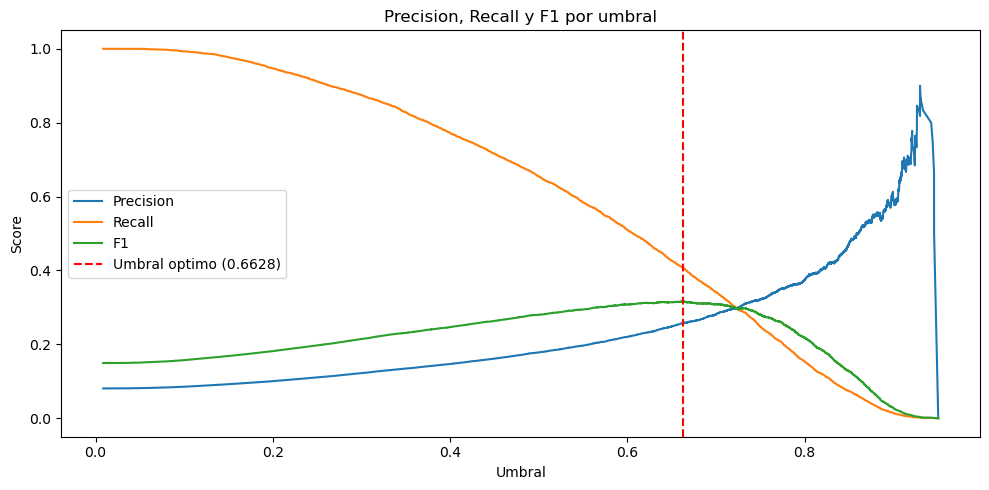

In [19]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(thresholds, precision[:-1], label='Precision')
ax.plot(thresholds, recall[:-1], label='Recall')
ax.plot(thresholds, f1_scores, label='F1')

ax.axvline(x=umbral_optimo, color='red', linestyle='--', label=f'Umbral optimo ({umbral_optimo:.4f})')

ax.set_title('Precision, Recall y F1 por umbral')
ax.set_xlabel('Umbral')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('../Reports/figures/10_threshold_tuning.png', dpi=150)
plt.show()

In [20]:
y_pred_060 = (y_prob >= 0.50).astype(int)
print(classification_report(y_test, y_pred_060, target_names=['Paga', 'Impago']))

              precision    recall  f1-score   support

        Paga       0.96      0.74      0.83     56538
      Impago       0.18      0.65      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.56     61503
weighted avg       0.90      0.73      0.79     61503



Con un umbral de decision de 0.50 conseguimos aumentar el recall a 0.65.

#### Explicabilidad con SHAP

In [54]:
import shap
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

explainer = shap.TreeExplainer(lgbm_final)

shap_values_raw = explainer.shap_values(X_test)

shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw

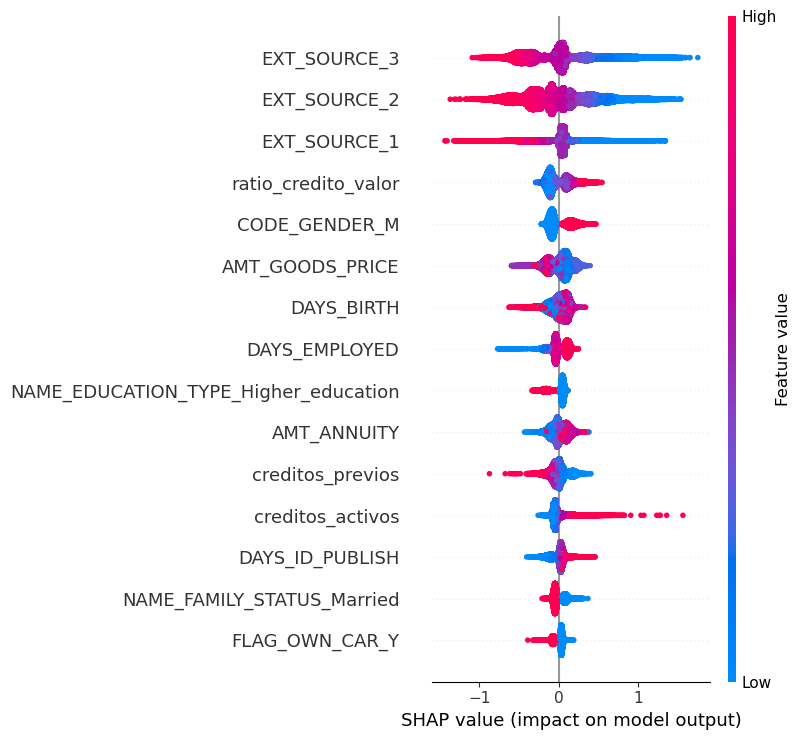

In [55]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), max_display=15)

In [23]:
features_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'shap_mean': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_mean', ascending=False).head(10)

features_importance

,feature,shap_mean
31,EXT_SOURCE_3,0.347013
30,EXT_SOURCE_2,0.342369
29,EXT_SOURCE_1,0.159228
162,ratio_credito_valor,0.123978
168,CODE_GENDER_M,0.119349
4,AMT_GOODS_PRICE,0.117036
6,DAYS_BIRTH,0.089371
7,DAYS_EMPLOYED,0.082970
185,NAME_EDUCATION_TYPE_Higher education,0.080002
3,AMT_ANNUITY,0.078522


Las fuestes externas de scoring son el predictor más importante para el modelo, por encima de variables internas como tipo de empleo o ingresos.

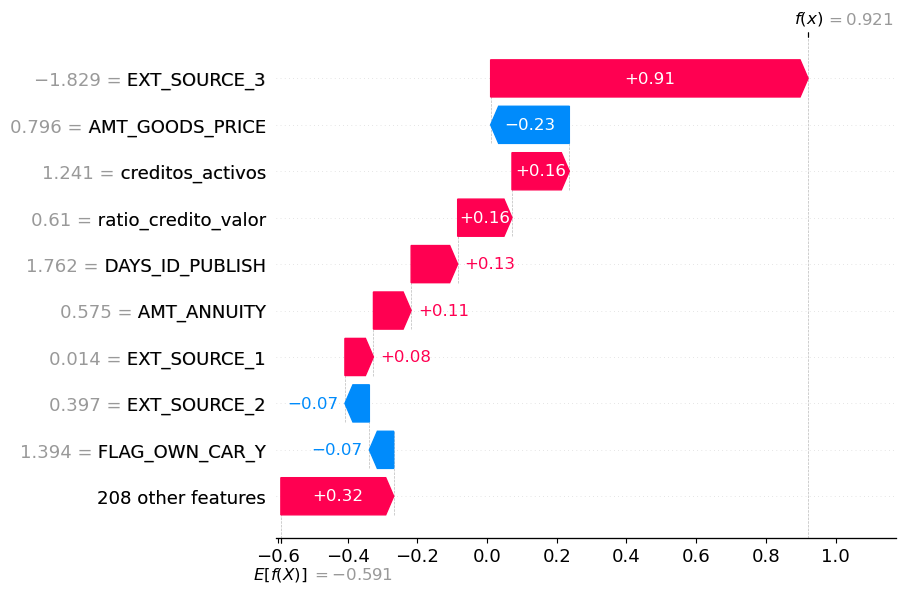

In [51]:
# Caso de impago predicho correctamente
impagos_correctos = np.where((y_pred_final == 1) & (y_test.values == 1))[0]

caso = impagos_correctos[0]

base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[caso],
        base_values= base_value,
        data=X_test.iloc[caso],
        feature_names= X.columns.tolist()
    )
)

Resumen de modelos

In [25]:
resumen_modelos = pd.DataFrame({
    'Modelo': ['DummyClassifier', 'Random Forest', 'Logistic Regression', 'LightGBM'],
    'AUC-ROC': [0.5, scores_rf.mean(), scores.mean(), scores_lgb.mean()],
    'Std': [0, scores_rf.std(), scores.std(), scores_lgb.std()]
})

resumen_modelos.sort_values('AUC-ROC', ascending=False)

,Modelo,AUC-ROC,Std
3,LightGBM,0.758873,0.005475
2,Logistic Regression,0.747511,0.004721
1,Random Forest,0.722457,0.003937
0,DummyClassifier,0.500000,0.000000


Despues de haber entrenado y probado los tres modelos, hemos obtenido los siguientes resultados:
- LightGBM fue el mejor modelo con mejores resultados con un AUC-ROC = 0.7589.
- Se pudo determinar que con umbral de decisión de 0.50, basado en la curva Precision-Recall, se logra aumentar el Recall para detectar el 65% de los impagos reales.
- Las variables de mayor peso para el modelo LightGBM fueron los scoring de credito externos para predecir si un cliente pagará o no, con un shap_medio = 0.283.